# CEX–DEX arbitrage

Hourly pipeline: data → calibration → HJB → backtest.



In [25]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
import pickle

warnings.filterwarnings('ignore')

_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 10})
%matplotlib inline
np.random.seed(42)

from arb.analysis import (
    bootstrap_ci_table,
    compute_descriptive_stats,
    compute_period_backtest,
    compute_q_regime_grid,
    compute_regime_comparison,
    compute_sensitivity_surface,
    detect_regimes,
    paired_ttest_strategies,
)
from arb.backtest import (
    backtest_summary,
    bootstrap_pnl,
    compute_sharpe,
    monte_carlo_eval,
    run_backtest,
    walk_forward_backtest,
)
from arb.calibrate import build_state_df, calibrate_all, calibrate_lambda_beta
from arb.config import *
from arb.models import build_A_t, build_K_t, g_closedform, mean_risk_objective
from arb.data import (
    binance_klines,
    binance_klines_paginated,
    binance_perp_klines,
    build_aligned,
    build_dex_1min_from_swaps,
    etherscan_gas_oracle,
    fetch_block_range_parallel,
    load_block_history,
    load_gecko_hourly,
    load_pool_hourly,
    load_pool_swaps,
)
from arb.hjb import solve_hjb_1d, solve_hjb_2d_xy
from arb.plots import (
    plot_2d_hjb_heatmap,
    plot_J_grid,
    plot_backtest,
    plot_correlation,
    plot_drift_check,
    plot_hjb_solution,
    plot_lambda_fit,
    plot_q_regime_heatmap,
    plot_regime_comparison,
    plot_returns_histogram_qq,
    plot_returns_rolling_vol,
    plot_sensitivity_surface_g_tau,
    plot_sensitivity_surface_sharpe,
    plot_2d_hjb_heatmap,
    savefig,
)

NB_OUT = Path(NB_ARTIFACT_DIR)
NB_OUT.mkdir(parents=True, exist_ok=True)
(NB_OUT / 'figures').mkdir(exist_ok=True)
print(NB_OUT)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/aeshef/Desktop/CAREER & STUDIES/DIPЛОМ/Диплом/outputs


## 1. Data


In [26]:
cex_1h = binance_klines_paginated(
    CEX_SYMBOL, interval='1h', start_str='2021-01-01', use_cache=True
)
print(len(cex_1h), cex_1h.index[0].date(), cex_1h.index[-1].date())

cex_1d = binance_klines_paginated(
    CEX_SYMBOL, interval='1d', start_str='2020-01-01', use_cache=True
)
perp_1h = binance_perp_klines(PERP_SYMBOL, interval='1h', limit=1000)


46800 2021-01-01 2026-05-05


In [27]:
dex_1h = load_pool_hourly(POOL_ADDRESS, pages=60, use_cache=True)
swaps = load_pool_swaps(POOL_ADDRESS, pages=50, use_cache=True)
if dex_1h.empty:
    dex_1h = load_gecko_hourly(limit=1000, pages=10, use_cache=True)
assert not dex_1h.empty

px_1m = build_dex_1min_from_swaps(swaps)
if px_1m.empty:
    cache = DATA_DIR / 'hft_cache'
    for p in sorted(cache.glob('swaps_*.parquet')) if cache.exists() else []:
        sw = pd.read_parquet(p)
        raw = sw.set_index('dt')['dex_price'].sort_index()
        raw = raw[(raw > 100) & (raw < 1e6)]
        px_1m = raw.resample('1min').last().ffill(limit=5).rename('dex_mid').to_frame()
        if not px_1m.empty:
            break
print(len(dex_1h), len(swaps), len(px_1m))


43841 50000 49166


In [28]:
gas_oracle = etherscan_gas_oracle()
blocks = load_block_history(n_blocks=200, use_cache=True)

hist_specs = load_historical_blocks()
hist_blocks = {}
for name, spec in hist_specs.items():
    df = fetch_block_range_parallel(
        start_block=int(spec['start_block']),
        total_range=int(spec['total_range']),
        n_samples=int(spec.get('n_samples', 300)),
        use_cache=True,
    )
    hist_blocks[name] = df
    if not df.empty and 'baseFee_gwei' in df.columns:
        print(name, len(df), df['baseFee_gwei'].median())


sep2021_nft 301 59.794955411
congested_dec2021 301 72.638566728
moderate_may2022 301 42.640729627
jun2022_terra 301 31.677102568
nov2022_ftx 301 10.519370404
mar2023_banking 301 21.01946252
aug2023_bald 301 17.114876642
mar2024_dencun 301 44.056245794


In [29]:
px = build_aligned(cex_1h, dex_1h, perp_1h if not perp_1h.empty else None)
print(len(px), px.index[0], px.index[-1])


43812 2021-05-05 19:00:00+00:00 2026-05-05 13:00:00+00:00


In [30]:
desc_stats = compute_descriptive_stats(px, blocks=blocks)
print(desc_stats)


                              N       Mean       Std       Min     Median  \
Variable                                                                    
CEX price S^C (USD)       43812  2574.0496  888.2536  904.2500  2480.8450   
DEX mid price S^D (USD)   43812  2574.2163  888.4617  900.8808  2480.2694   
Spread |S^C − S^D| (USD)  43812     1.8506    4.9005    0.0001     1.0654   
Spread (bps)              43812     7.3659   26.0070    0.0005     4.5916   
CEX log-return (hourly)   43811    -0.0009    0.7909  -14.0175     0.0044   
DEX log-return (hourly)   43811    -0.0008    0.8051  -15.7863     0.0058   
Base fee (gwei)             200     0.2096    0.0449    0.1244     0.2122   

                                Max     Skew       Kurt  Freq  
Variable                                                       
CEX price S^C (USD)       4935.0000   0.3945    -0.7471    1h  
DEX mid price S^D (USD)   4935.0286   0.3956    -0.7447    1h  
Spread |S^C − S^D| (USD)   308.3809  24.7444   991

## 2. Calibration


In [31]:
assert not blocks.empty
params = calibrate_all(px, blocks, gas_oracle, swaps=swaps, Q=Q_ETH)
params['gamma'] = GAMMA
print(params['sigma_d'], params['sigma_c'], params['rho'], params['kappa'], params['beta'])
S0 = params['S0']


0.7535315174355186 0.7402062683624429 0.9690838934519578 27618.655904756088 3.5628696201071683


In [32]:
state = build_state_df(px, params, Q=Q_ETH)
state = detect_regimes(state)
opp_base = state[state['is_opp']].copy()
print(len(state), len(opp_base))


43788 10966


## 3. Stylized facts


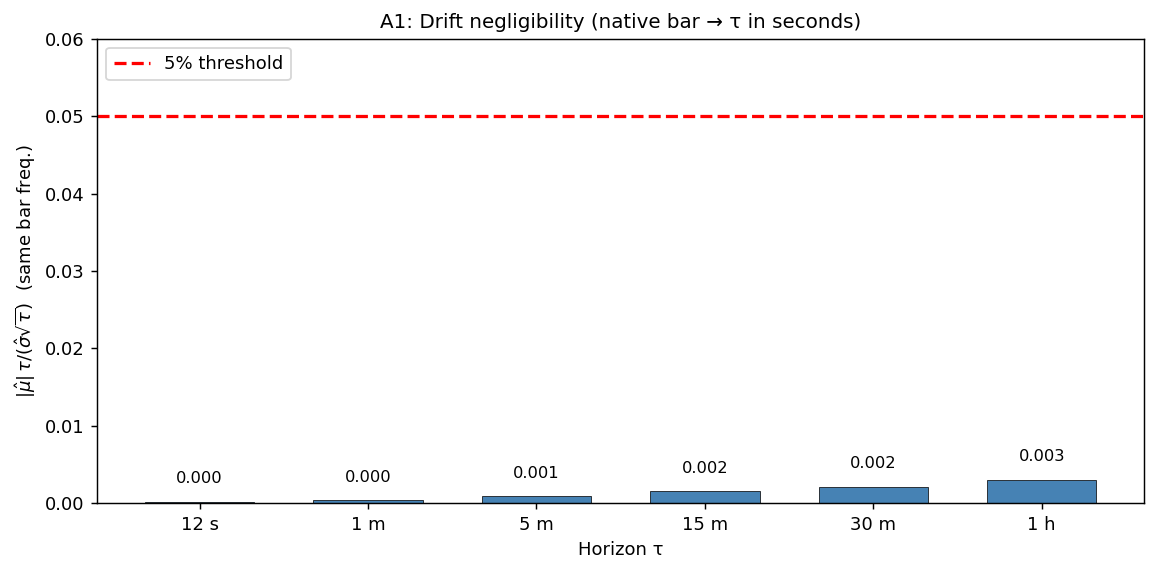

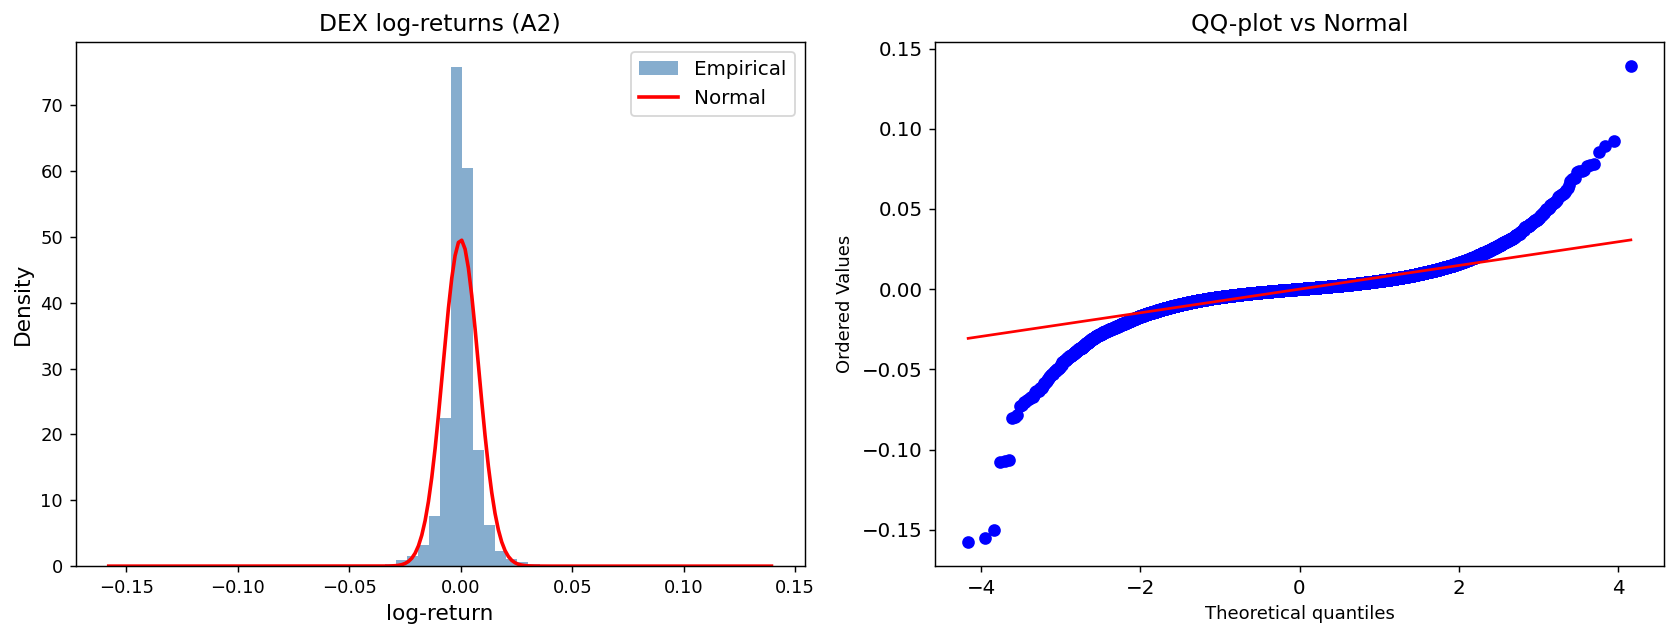

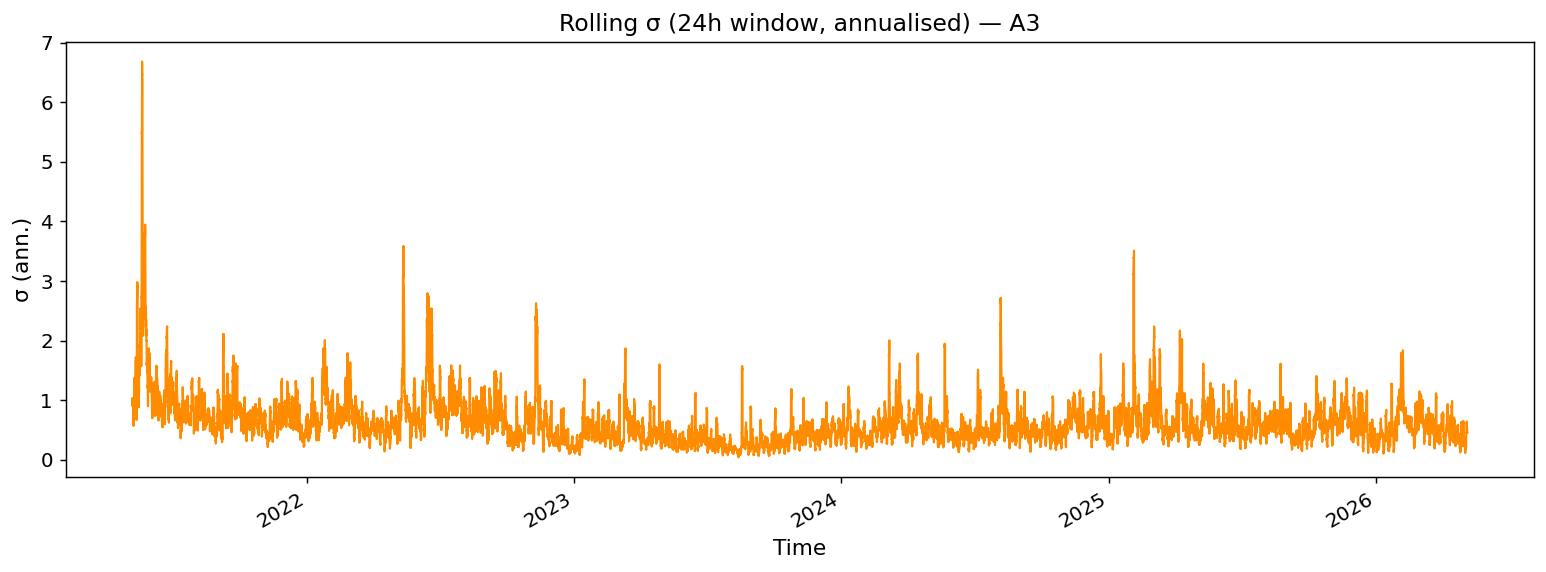

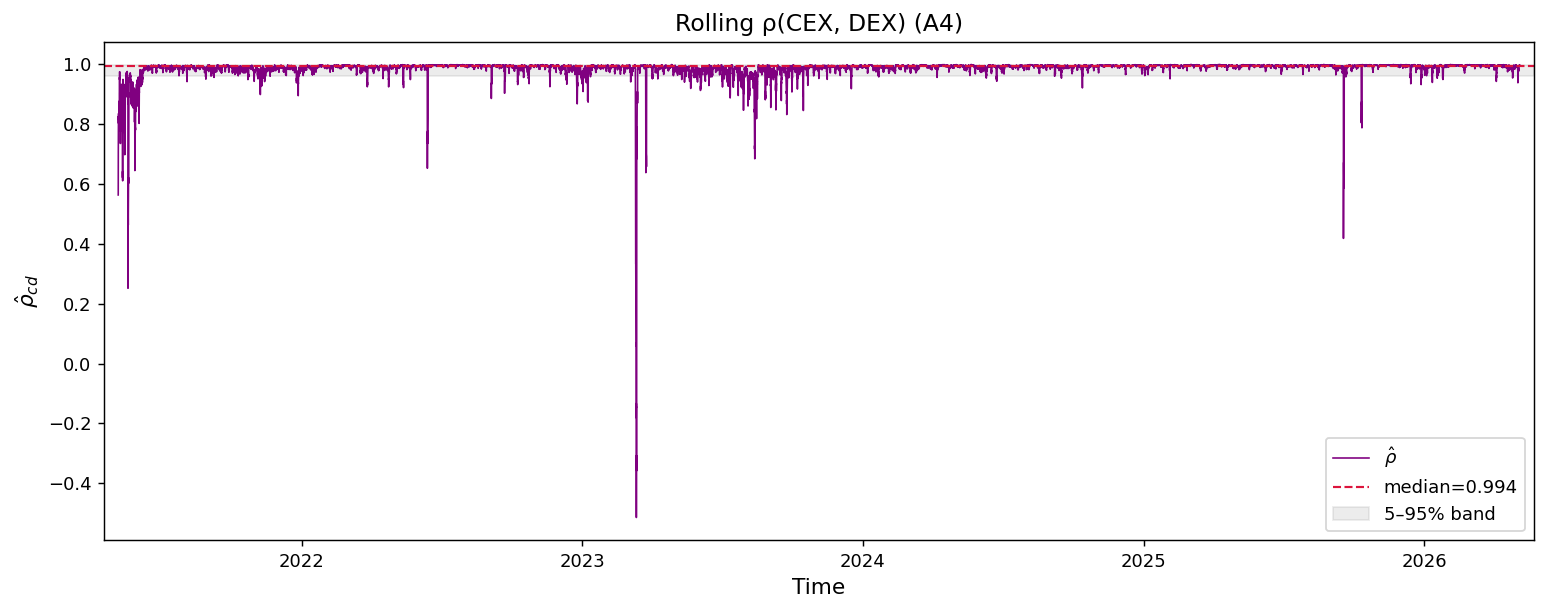

In [33]:
assert not cex_1h.empty
fig = plot_drift_check(cex_1h); savefig(fig, 'drift'); plt.show()

fig = plot_returns_histogram_qq(px); savefig(fig, 'hist_qq'); plt.show()
fig = plot_returns_rolling_vol(px, roll_h=ROLL_H); savefig(fig, 'rolling_vol'); plt.show()

fig = plot_correlation(px, roll_h=ROLL_H)
savefig(fig, 'correlation'); plt.show()

rho_roll = px['ret_cex'].rolling(ROLL_H).corr(px['ret_dex'])
log_ret_h = np.log(cex_1h['close']).diff().dropna()
mu_h, sig_h = log_ret_h.mean(), log_ret_h.std()
tau_h = 1.0


## 4. HJB


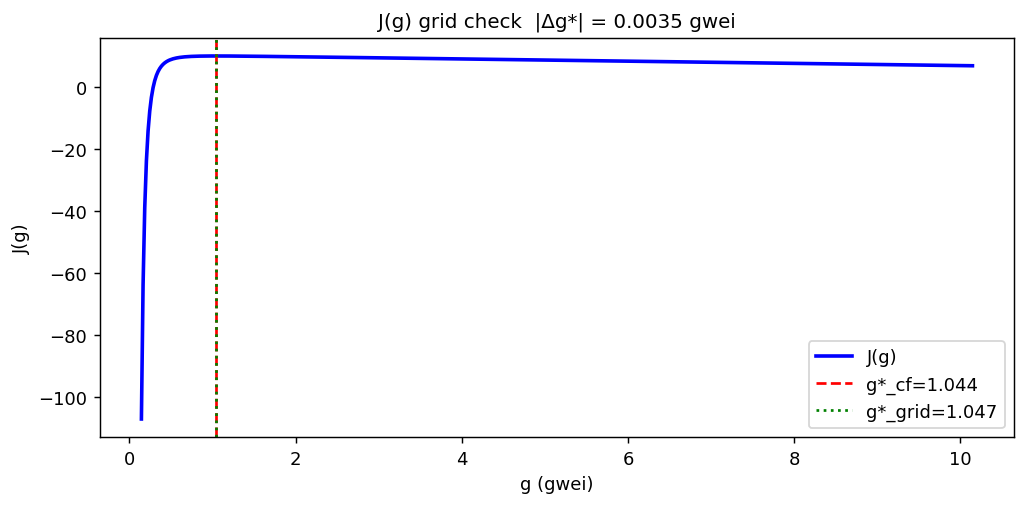

In [34]:
sig_d_h = params['sigma_d'] / np.sqrt(365 * 24)
K_ref = build_K_t(Q_ETH, S0, sig_d_h, params['rho'])
A_ref = build_A_t(Q_ETH, S0, sig_d_h, params['slip_alpha'], params['slip_beta'])
g_test = np.linspace(params['g_lo'], params['g_hi'], 500)
delta_ref = float(px['spread_usd'].abs().median())
J_grid = np.array([
    mean_risk_objective(
        g, K_ref, A_ref, S0, Q_ETH, delta_ref,
        params['kappa'], params['beta'], GAMMA,
    )
    for g in g_test
])
g_star_grid = g_test[np.argmax(J_grid)]
g_star_cf = g_closedform(
    K_ref, A_ref, S0, params['kappa'], params['beta'], GAMMA,
    g_lo=params['g_lo'], g_hi=params['g_hi'],
)
fig = plot_J_grid(g_test, J_grid, g_star_cf, g_star_grid)
savefig(fig, 'J_grid')
plt.show()


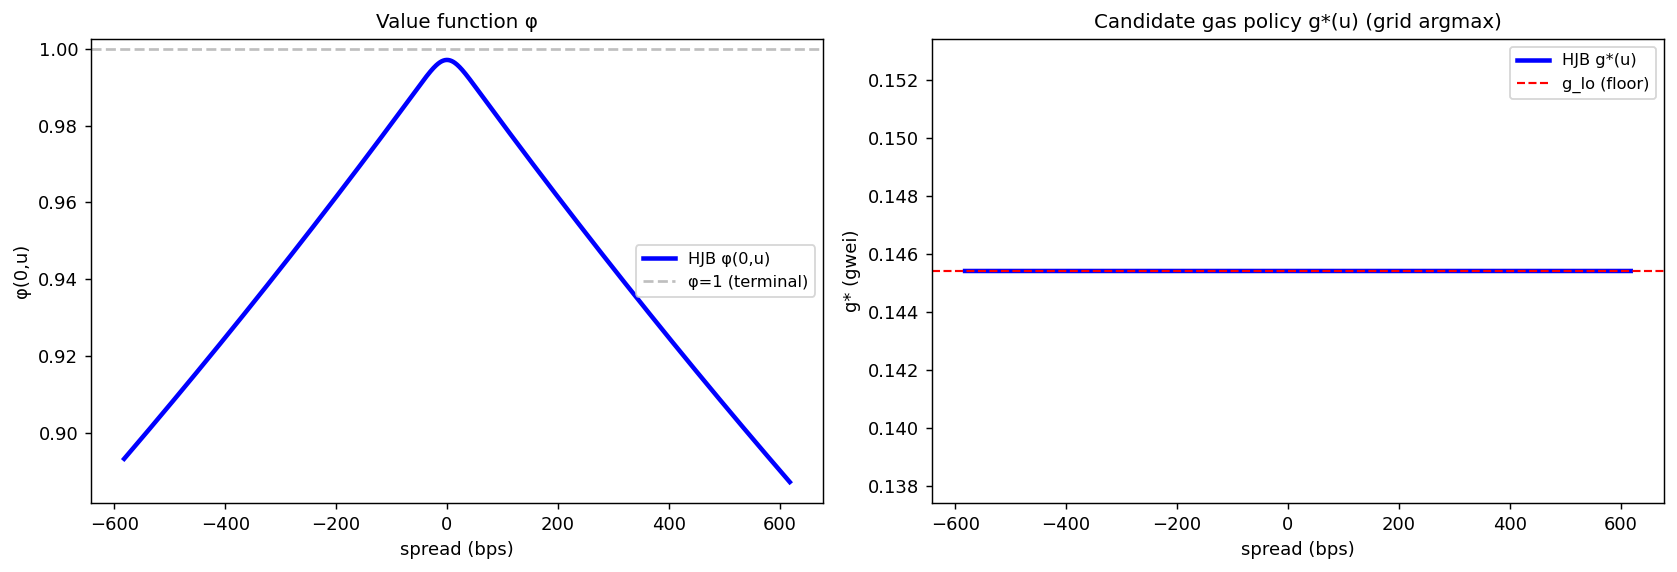

In [35]:
u_hjb, phi_hjb, g_star_hjb = solve_hjb_1d(
    params, T_horizon=T_HORIZON, N_z=N_Z_HJB, N_t=N_T_HJB, gamma=GAMMA, Q=Q_ETH,
)
fig = plot_hjb_solution(u_hjb, phi_hjb, g_star_hjb, params=params)
savefig(fig, 'hjb_1d')
plt.show()


In [36]:
cache = NB_OUT / 'cache'
cache.mkdir(exist_ok=True)
with open(cache / 'params.pkl', 'wb') as f:
    pickle.dump(params, f)
with open(cache / 'hjb_grids.pkl', 'wb') as f:
    pickle.dump({'u_grid': u_hjb, 'g_star': g_star_hjb, 'phi': phi_hjb}, f)


In [37]:
if HJB_CONVERGENCE_CHECK:
    N_ref = min(N_Z_HJB_HEAVY, 4000)
    u2, phi2, g2 = solve_hjb_1d(params, N_z=N_ref, N_t=N_T_HJB_HEAVY,
                                  gamma=GAMMA, Q=Q_ETH)
    phi_ref_on_base = np.interp(u_hjb, u2, phi2)
    g_ref_on_base   = np.interp(u_hjb, u2, g2)
    max_phi_err = np.max(np.abs(phi_hjb - phi_ref_on_base))
    max_g_err   = np.max(np.abs(g_star_hjb - g_ref_on_base))
    print(max_phi_err, max_g_err)


1.527027283509952e-07 0.0


## 5. Backtest


HJB 10966 332086.76 0.236
CF 10966 342034.64 0.4
Naive 10966 336331.04 0.216


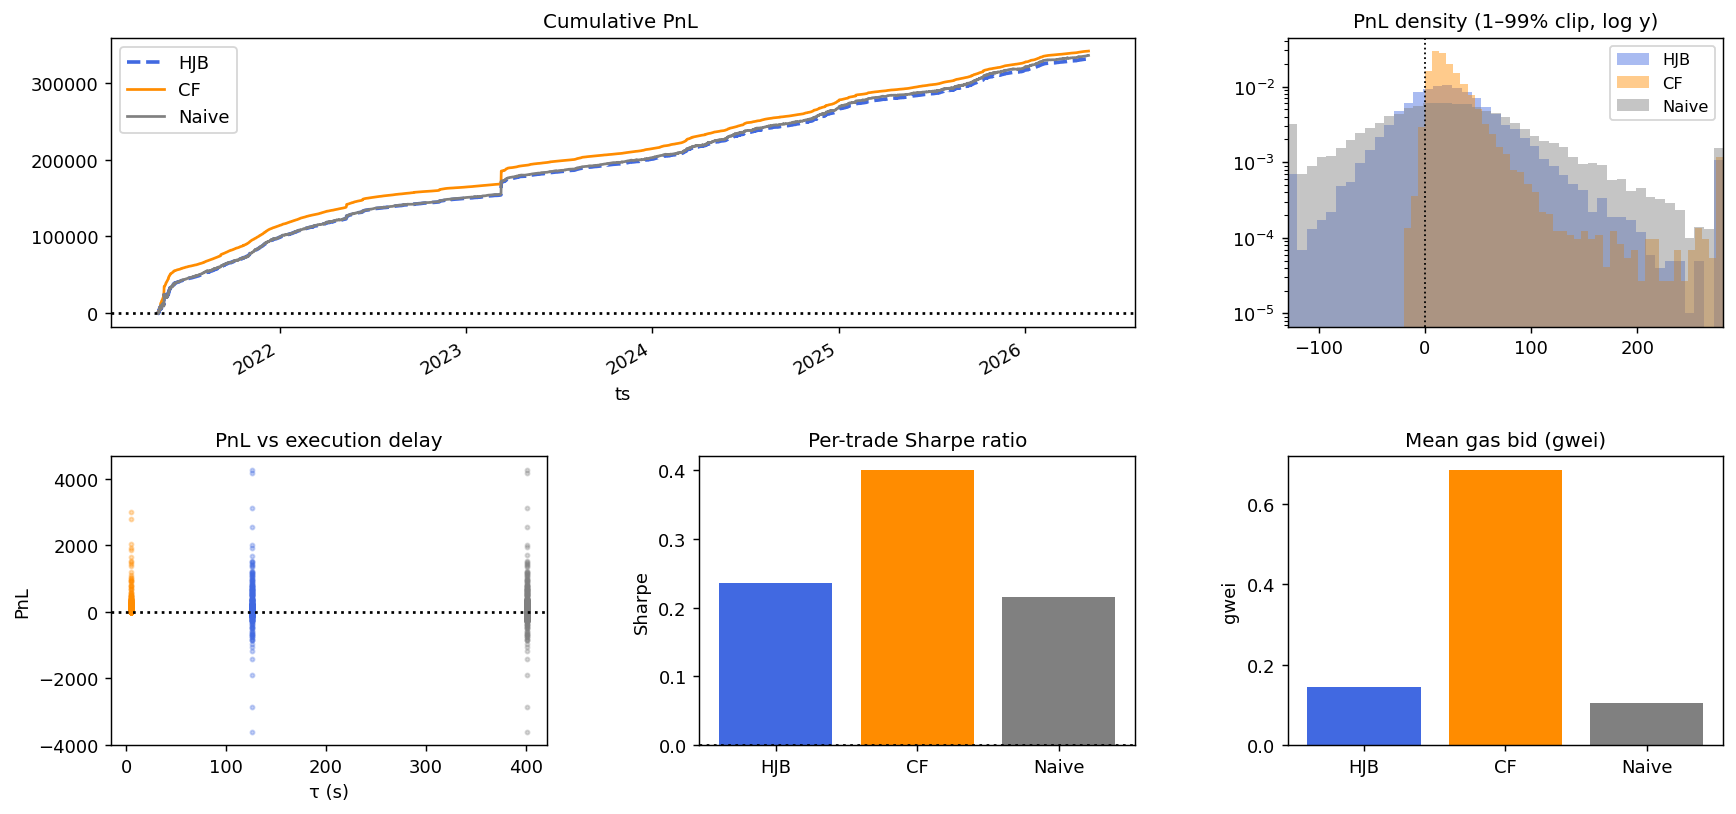

  strategy      n  mean_delta   std_delta  t_stat  p_value  significant
0      HJB  10966   -0.387040   31.972440  -1.268   0.8975        False
1       CF  10966    0.520117  117.231117   0.465   0.3211        False
       n_trades      total_pnl   mean_pnl     std_pnl    sharpe  win_rate  \
label                                                                       
HJB       10966  332086.758147  30.283308  128.516159  0.235649  0.719861   
CF        10966  342034.636663  31.190465   77.975300  0.400023  0.978388   
Naive     10966  336331.035726  30.670348  141.858999  0.216213  0.640525   

       mean_g_gwei  mean_tau_s  
label                           
HJB       0.145407  125.517006  
CF        0.684037    5.000000  
Naive     0.104962  400.898608  
  strategy    mean_lo    mean_hi  sharpe_lo  sharpe_hi
0      HJB  27.965834  32.691641   0.201648   0.283600
1       CF  29.691695  32.833063   0.339626   0.489829
2    Naive  28.109805  33.358800   0.188513   0.252080


In [38]:
dex_series = px_1m['dex_mid'] if not px_1m.empty else px['dex_mid']
def hjb_pol(row):
    u = np.log(max(float(row['cex_close']) / max(float(row.get('dex_mid', row['cex_close'])), 1e-6), 1e-6))
    return float(np.interp(np.clip(u, u_hjb[0], u_hjb[-1]), u_hjb, g_star_hjb))
def cf_pol(row):
    return g_closedform(
        row.get('K_t', K_ref), row.get('A_t', A_ref),
        float(row['cex_close']), params['kappa'], params['beta'], GAMMA,
        g_lo=params['g_lo'], g_hi=params['g_hi'],
    )
def naive_pol(row):
    return float(params.get(NAIVE_GAS_FIELD, params.get('propose_gwei', params['g_lo'])))
bt_dict = {
    'HJB': run_backtest(opp_base, hjb_pol, 'HJB', params, dex_series=dex_series),
    'CF': run_backtest(opp_base, cf_pol, 'CF', params, dex_series=dex_series),
    'Naive': run_backtest(opp_base, naive_pol, 'Naive', params, dex_series=dex_series),
}
fig = plot_backtest(bt_dict)
savefig(fig, 'backtest')
plt.show()
print(paired_ttest_strategies(bt_dict, reference='Naive'))
print(pd.DataFrame([backtest_summary(bt, n) for n, bt in bt_dict.items() if not bt.empty]).set_index('label'))
print(bootstrap_ci_table(bt_dict))


## 6. Gas regimes


In [39]:
gas_regimes = {'calm_current': dict(params)}

for name, blk in hist_blocks.items():
    if blk.empty or 'baseFee_gwei' not in blk.columns:
        continue
    k, b, _ = calibrate_lambda_beta(blk['baseFee_gwei'].dropna().values)
    if k is None:
        continue
    p = dict(params)
    bf = blk['baseFee_gwei']
    p.update({
        'kappa': k,
        'beta': b,
        'base_fee': float(bf.median()),
        'propose_gwei': float(bf.quantile(0.7)),
        'g_lo': float(bf.median()) + 0.05,
        'g_hi': float(bf.quantile(0.95)) * 2.0,
    })
    gas_regimes[name] = p

for rname, synth in SYNTH_REGIMES.items():
    if rname in gas_regimes:
        continue
    p = dict(params)
    p.update(synth)
    p['g_lo'] = synth['base_fee'] + 0.05
    p['g_hi'] = synth['propose_gwei'] * 3.0
    gas_regimes[rname] = p


In [40]:
gas_regimes = {'calm_current': dict(params)}

for name, blk in hist_blocks.items():
    if blk.empty or 'baseFee_gwei' not in blk.columns:
        continue
    k, b, _ = calibrate_lambda_beta(blk['baseFee_gwei'].dropna().values)
    if k is None:
        continue
    p = dict(params)
    bf = blk['baseFee_gwei']
    p.update({
        'kappa': k,
        'beta': b,
        'base_fee': float(bf.median()),
        'propose_gwei': float(bf.quantile(0.7)),
        'g_lo': float(bf.median()) + 0.05,
        'g_hi': float(bf.quantile(0.95)) * 2.0,
    })
    gas_regimes[name] = p

for rname, synth in SYNTH_REGIMES.items():
    if rname in gas_regimes:
        continue
    p = dict(params)
    p.update(synth)
    p['g_lo'] = synth['base_fee'] + 0.05
    p['g_hi'] = synth['propose_gwei'] * 3.0
    gas_regimes[rname] = p


HJB [calm_current] 10966 332086.76 0.236
CF [calm_current] 10966 342034.64 0.4
Naive [calm_current] 10966 338082.61 0.207
HJB [sep2021_nft] 10966 86742.68 0.094
CF [sep2021_nft] 10966 73524.84 0.089
Naive [sep2021_nft] 10966 31495.5 0.035
HJB [congested_dec2021] 10966 28984.93 0.028
CF [congested_dec2021] 10966 13043.28 0.016
Naive [congested_dec2021] 10966 -42809.04 -0.044
HJB [moderate_may2022] 10966 160703.79 0.18
CF [moderate_may2022] 10966 151312.47 0.183
Naive [moderate_may2022] 10966 61651.21 0.07
HJB [jun2022_terra] 10966 205826.88 0.221
CF [jun2022_terra] 10966 192839.47 0.233
Naive [jun2022_terra] 10966 154804.29 0.17
HJB [nov2022_ftx] 10966 291797.84 0.269
CF [nov2022_ftx] 10966 282991.44 0.326
Naive [nov2022_ftx] 10966 289185.41 0.276
HJB [mar2023_banking] 10966 253138.99 0.288
CF [mar2023_banking] 10966 247818.87 0.293
Naive [mar2023_banking] 10966 226906.01 0.259
HJB [aug2023_bald] 10966 268830.63 0.299
CF [aug2023_bald] 10966 262960.69 0.31
Naive [aug2023_bald] 10966 244

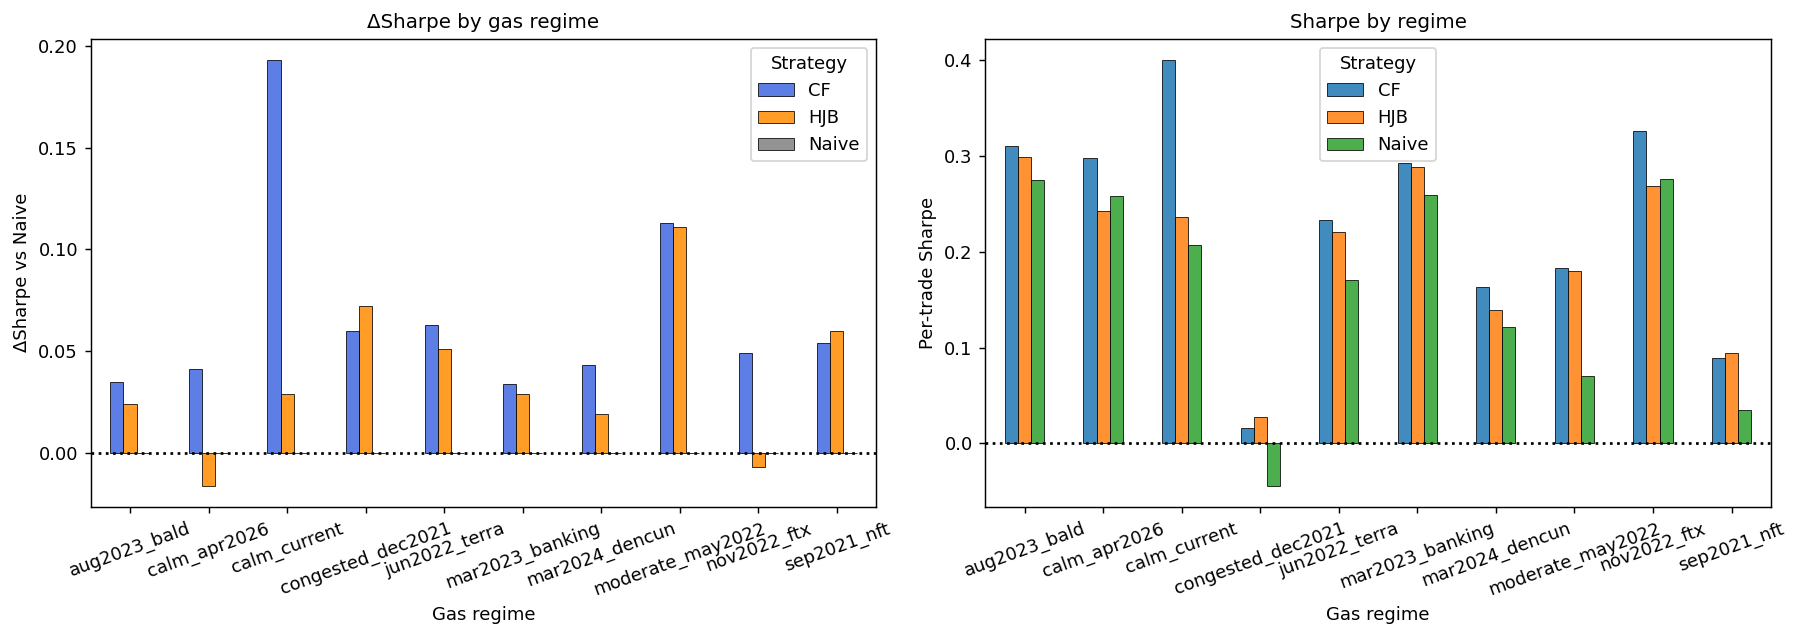

In [41]:
regime_comp = compute_regime_comparison(
    opp_base, params, gas_regimes, u_hjb, g_star_hjb, dex_series=dex_series, Q=Q_ETH,
)
print(regime_comp.round(3))
fig = plot_regime_comparison(regime_comp)
if fig:
    savefig(fig, 'regime_cmp')
    plt.show()


In [42]:
gas_regimes = {'calm_current': dict(params)}

for name, blk in hist_blocks.items():
    if blk.empty or 'baseFee_gwei' not in blk.columns:
        continue
    k, b, _ = calibrate_lambda_beta(blk['baseFee_gwei'].dropna().values)
    if k is None:
        continue
    p = dict(params)
    bf = blk['baseFee_gwei']
    p.update({
        'kappa': k,
        'beta': b,
        'base_fee': float(bf.median()),
        'propose_gwei': float(bf.quantile(0.7)),
        'g_lo': float(bf.median()) + 0.05,
        'g_hi': float(bf.quantile(0.95)) * 2.0,
    })
    gas_regimes[name] = p

for rname, synth in SYNTH_REGIMES.items():
    if rname in gas_regimes:
        continue
    p = dict(params)
    p.update(synth)
    p['g_lo'] = synth['base_fee'] + 0.05
    p['g_hi'] = synth['propose_gwei'] * 3.0
    gas_regimes[rname] = p


## 6.2 Sensitivity


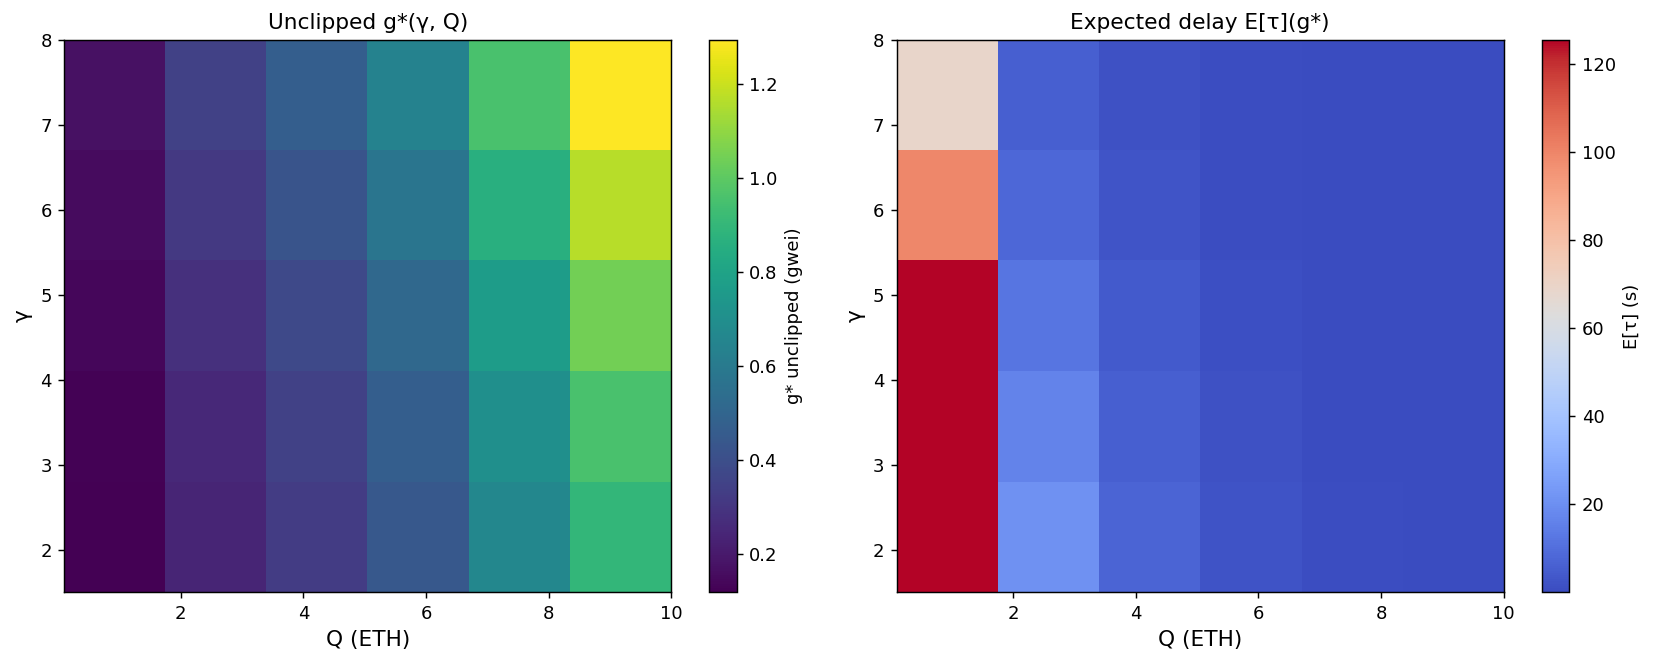

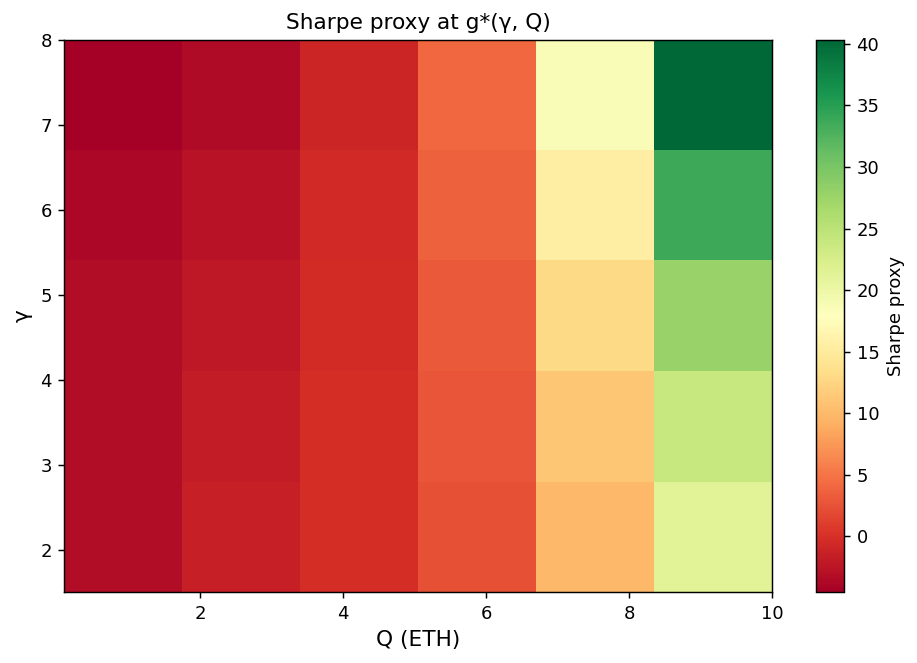

In [43]:
gammas_s = np.array([1.5, 2.0, 3.0, 5.0, 8.0])
Qs_s = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 10.0])
median_sp = float(px['spread_usd'].abs().median()) if not px.empty else 0.5

g_surf, g_raw_surf, tau_surf, sh_surf = compute_sensitivity_surface(
    params, gammas_s, Qs_s, median_spread_usd=median_sp, S=S0)

fig = plot_sensitivity_surface_g_tau(gammas_s, Qs_s, g_raw_surf, tau_surf)
savefig(fig, 'sens_g_tau'); plt.show()
fig = plot_sensitivity_surface_sharpe(gammas_s, Qs_s, sh_surf)
savefig(fig, 'sens_sharpe'); plt.show()


## 2D HJB


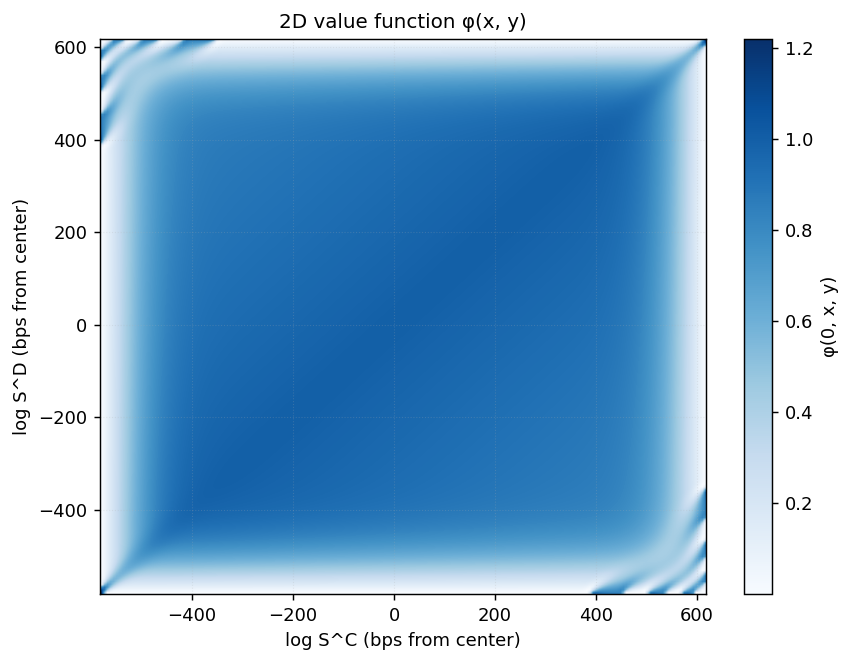

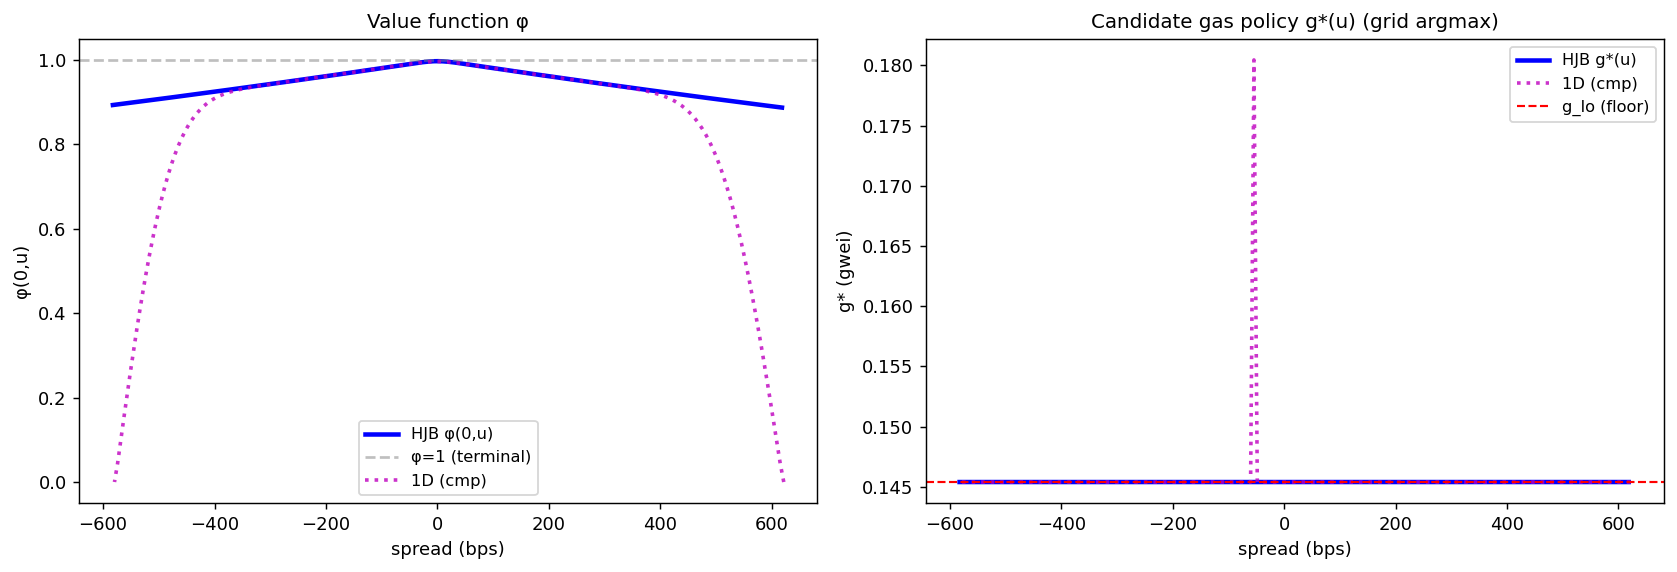

In [44]:
if HJB_2D_ACTIVE:
    xg_2d, yg_2d, phi_2d, g_star_2d, meta_2d = solve_hjb_2d_xy(
        params, T_horizon=T_HORIZON,
        Nx=N_X_HJB_XY, Ny=N_Y_HJB_XY, N_t=N_T_HJB_XY,
        gamma=GAMMA, Q=Q_ETH, n_g=G_SCAN,
        )

    _hjb2d_cache = NB_OUT / 'figures' / 'hjb_2d_xy_cache.npz'
    np.savez_compressed(_hjb2d_cache, xg_2d=xg_2d, yg_2d=yg_2d, phi_2d=phi_2d, g_star_2d=g_star_2d)

    fig = plot_2d_hjb_heatmap(xg_2d, yg_2d, phi_2d, g_star_2d)
    savefig(fig, 'hjb_2d'); plt.show()

    mid_ix = len(xg_2d) // 2
    u_2d_slice    = xg_2d[mid_ix] - yg_2d
    phi_2d_slice  = phi_2d[:, mid_ix]
    g_2d_slice    = g_star_2d[:, mid_ix]

    fig = plot_hjb_solution(u_hjb, phi_hjb, g_star_hjb, params=params,
                            u_1d=u_2d_slice, phi_1d=phi_2d_slice, g_1d=g_2d_slice)
    savefig(fig, 'hjb_2d_vs_1d'); plt.show()


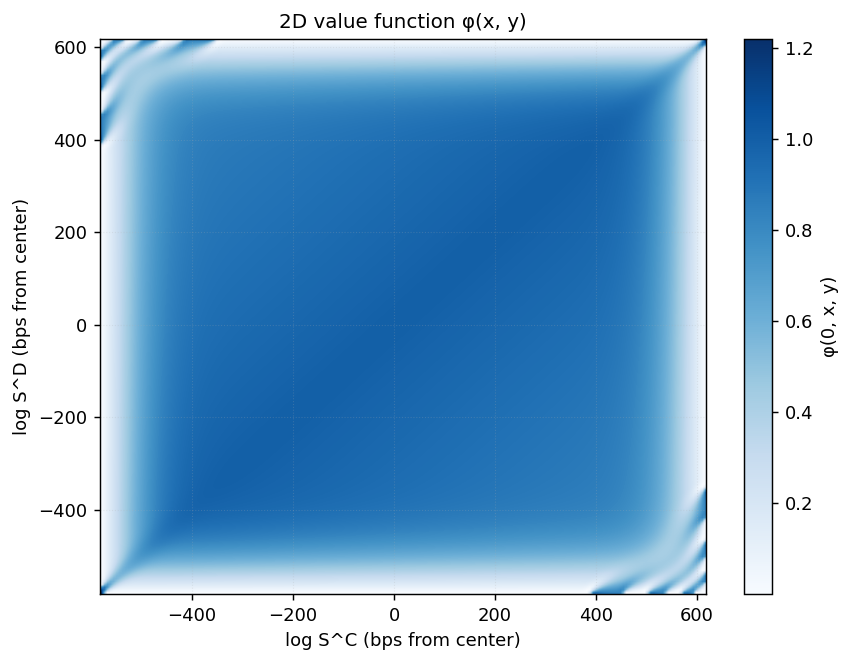

In [45]:
cache_npz = NB_OUT / 'figures' / 'hjb_2d_xy_cache.npz'
z = np.load(cache_npz)
fig = plot_2d_hjb_heatmap(z['xg_2d'], z['yg_2d'], z['phi_2d'], z['g_star_2d'])
savefig(fig, 'hjb_2d')
plt.show()


## 5.2 Walk-forward


In [46]:
wf_results = walk_forward_backtest(
    state, params, u_hjb, g_star_hjb,
    dex_series=px_1m['dex_mid'] if not px_1m.empty else px['dex_mid'],
    wf_train=WF_TRAIN, wf_test=WF_TEST,
)
print(len(wf_results))


HJB 36 3266.31 0.159
CF 36 9621.84 2.801
Naive 36 3266.85 0.159
HJB 36 9774.07 0.577
CF 36 7637.94 1.862
Naive 36 9774.61 0.577
HJB 39 4304.1 0.305
CF 39 3419.35 1.85
Naive 39 4318.57 0.306
HJB 41 1544.41 0.927
CF 41 1380.71 2.209
Naive 41 1695.15 0.606
HJB 42 1460.75 1.145
CF 42 1517.66 2.098
Naive 42 1396.07 0.639
HJB 44 1319.54 0.884
CF 44 1387.21 2.189
Naive 44 1244.2 0.498
HJB 39 1351.23 1.054
CF 39 1237.01 2.219
Naive 39 1455.39 0.645
HJB 38 1041.6 0.834
CF 38 924.29 1.589
Naive 38 1150.25 0.548
HJB 41 913.24 0.793
CF 41 939.21 2.46
Naive 41 880.86 0.433
HJB 40 1191.07 0.953
CF 40 1395.81 2.287
Naive 40 980.45 0.446
HJB 52 1479.08 0.721
CF 52 1627.36 1.153
Naive 52 1320.82 0.396
HJB 45 2000.08 0.893
CF 45 1877.31 2.532
Naive 45 2106.92 0.548
HJB 43 1931.44 0.935
CF 43 1852.2 2.902
Naive 43 1995.55 0.548
HJB 42 2147.83 1.074
CF 42 1718.04 2.806
Naive 42 2557.98 0.727
HJB 42 1595.77 0.783
CF 42 1743.68 2.97
Naive 42 1437.01 0.394
HJB 46 3521.04 0.526
CF 46 3552.06 0.603
Naive 46 34

## 5.2 Walk-forward


               HJB          CF       Naive
n       10966.0000  10966.0000  10966.0000
mean       30.2833     31.1905     30.6703
std       128.5103     77.9717    141.8525
sharpe      0.2356      0.4000      0.2162
VaR_95    -43.7379      2.7682    -95.8670
HJB 3.24547116249526e-42
CF 4.9882541829313705e-239


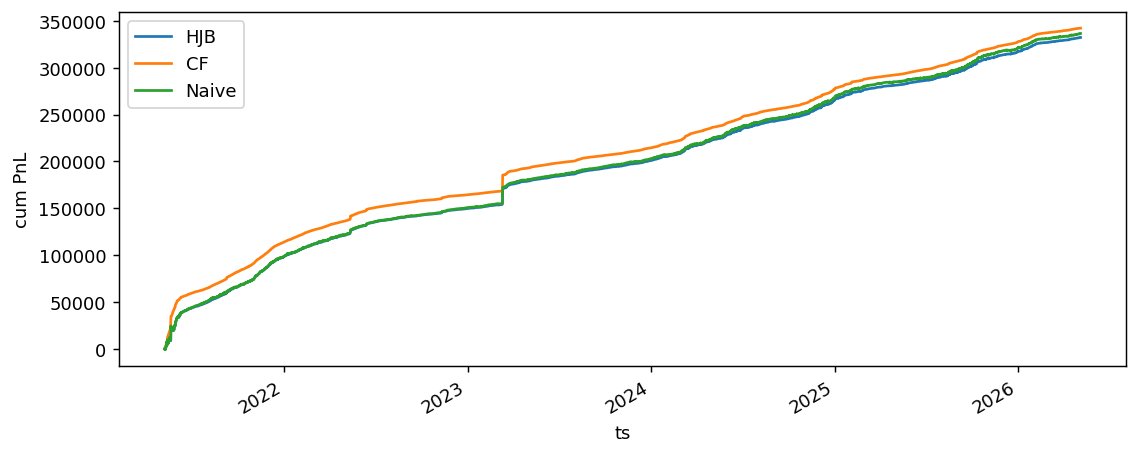

In [47]:
PNL_COL = 'net_pnl'
valid = {k: v for k, v in bt_dict.items() if v is not None and not v.empty}

def risk_row(bt):
    p = bt[PNL_COL].values.astype(float)
    return {
        'n': len(p),
        'mean': p.mean(),
        'std': p.std(),
        'sharpe': p.mean() / p.std() if p.std() > 0 else 0.0,
        'VaR_95': np.percentile(p, 5),
    }

print(pd.DataFrame({n: risk_row(bt) for n, bt in valid.items()}).round(4))
naive_p = valid['Naive'][PNL_COL].values
for nm in ('HJB', 'CF'):
    if nm in valid:
        _, p = levene(valid[nm][PNL_COL].values, naive_p)
        print(nm, p)

fig, ax = plt.subplots(figsize=(10, 4))
for nm, bt in valid.items():
    bt['cum_pnl'].plot(ax=ax, label=nm)
ax.legend()
ax.set_ylabel('cum PnL')
savefig(fig, 'risk_profile')
plt.show()
